<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn import tree

In [10]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
df1=df.copy()

In [12]:
# after removing the irrelevent columns

df1.drop(["class","who","adult_male","embark_town","alive"],axis=1,inplace=True)

In [13]:
# checking basics of data

print("Total_row & Columns:",df1.shape)
print("Targer_Variable:", "survived")


Total_row & Columns: (891, 10)
Targer_Variable: survived


In [14]:
# Now to check how many missing values are present in out dataset

Missing=df1.isnull().sum()

Missing_value=Missing[Missing>0]

Missing_value

,0
age,177
embarked,2
deck,688


In [15]:
#  From Above Code we can see that there are some missing values in percentages of missing values
missing2=(df1.isnull().mean().mul(100).sort_values(ascending=False).round(2))
print(missing2[missing2>0])

deck        77.22
age         19.87
embarked     0.22
dtype: float64


In [16]:
# As deck column has a very high missing value so insteated of filling it we will also remove them from the datafram

df1.drop("deck",axis=1,inplace=True)

In [17]:
# There are some missing values in two columns now we will filla them using medium as the medium will give use the mid value for age
# for embarked we will fill it with

df1['age']=df1["age"].fillna(df["age"].median())
df1['embarked']=df1["embarked"].fillna(df["embarked"].mode()[0])

In [18]:
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [19]:
# As we can see that now there are still some categorical columns and to building a Ml modela all columns should be of numrical form
# so we convert them into numrical columns instead of categorical by Encoders

df1["sex"]=df1["sex"].map({"male":1,
                           "female":0})

df1=pd.get_dummies(df1,columns=["embarked"],drop_first=True,dtype=int)

In [20]:
x=df1.drop("survived",axis=1)
y=df1["survived"]

In [21]:
model=DecisionTreeClassifier(criterion="gini",
                             random_state=42
                             )

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [23]:
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
y_pred=model.predict(x_test)

In [25]:
# Evaluate the model accuracy

print("Accuracy_score",accuracy_score(y_test,y_pred))


print("classification_mateix: ",classification_report(y_test,y_pred))


print("Confusion_matrix",confusion_matrix(y_test,y_pred))



Accuracy_score 0.7932960893854749
classification_mateix:                precision    recall  f1-score   support

           0       0.84      0.80      0.82       105
           1       0.73      0.78      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179

Confusion_matrix [[84 21]
 [16 58]]


In [26]:
# Multiple Decision tree by pruning

df1


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,0,1
1,1,1,0,38.0,1,0,71.2833,False,0,0
2,1,3,0,26.0,0,0,7.9250,True,0,1
3,1,1,0,35.0,1,0,53.1000,False,0,1
4,0,3,1,35.0,0,0,8.0500,True,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,True,0,1
887,1,1,0,19.0,0,0,30.0000,True,0,1
888,0,3,0,28.0,1,2,23.4500,False,0,1
889,1,1,1,26.0,0,0,30.0000,True,0,0


In [27]:
model2=DecisionTreeClassifier(max_depth=3,
                              min_samples_leaf=5,
                              max_leaf_nodes=10,
                              random_state=42)

In [28]:
model2.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=10, min_samples_leaf=5,
                       random_state=42)

In [29]:
y_pred2=model2.predict(x_test)

In [30]:
print("Accuracy_score",accuracy_score(y_test,y_pred2))
print("x"*80)
print("classification_mateix:",classification_report(y_test,y_pred2))
print("x"*80)
print("Confusion_matrix: ",confusion_matrix(y_test,y_pred2))

Accuracy_score 0.7988826815642458
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
classification_mateix:               precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Confusion_matrix:  [[92 13]
 [23 51]]


In [31]:
model=DecisionTreeClassifier(random_state=42)

In [32]:
# let;'s try with the which max_depth the accuracy score

for depth in range(1,11):
  model3=DecisionTreeClassifier(max_depth=depth, random_state=42)


  model3.fit(x_train,y_train)

  y_pred_train=model3.predict(x_train)
  y_pred_test=model3.predict(x_test)



  train_acc=accuracy_score(y_train,y_pred_train)
  # test_acc=accuracy_score(x_test,y_test)
  test_acc=accuracy_score(y_test,y_pred_test)

  print(f"max_depth:{depth}")
  print(f"tain_acc:{train_acc:.3f}")
  # print(f"test_acc:{test_acc:.3f}")
  print(f"test1_acc:{test_acc:.3f}")
  print("-"*40)

max_depth:1
tain_acc:0.788
test1_acc:0.782
----------------------------------------
max_depth:2
tain_acc:0.803
test1_acc:0.765
----------------------------------------
max_depth:3
tain_acc:0.834
test1_acc:0.799
----------------------------------------
max_depth:4
tain_acc:0.840
test1_acc:0.799
----------------------------------------
max_depth:5
tain_acc:0.851
test1_acc:0.799
----------------------------------------
max_depth:6
tain_acc:0.867
test1_acc:0.799
----------------------------------------
max_depth:7
tain_acc:0.883
test1_acc:0.799
----------------------------------------
max_depth:8
tain_acc:0.897
test1_acc:0.793
----------------------------------------
max_depth:9
tain_acc:0.907
test1_acc:0.799
----------------------------------------
max_depth:10
tain_acc:0.913
test1_acc:0.804
----------------------------------------


In [33]:
# Now try with GridSearchCV for multiple Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

param_grid={"max_depth":[2,4,5,7,10],
            "min_samples_leaf":[5,10,15],
            "criterion":["gini","entropy"]}

grid=GridSearchCV(estimator=model3,param_grid=param_grid,cv=5)

grid.fit(x_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10}
0.8187924751305033


In [34]:
# Checking the Feature_importance_

importance=model3.feature_importances_

print(importance)

[0.14384996 0.40394464 0.1554012  0.06325483 0.02303521 0.18930642
 0.         0.00305887 0.01814887]


In [35]:
importance_d=pd.DataFrame({"features":x_train.columns,"importance":model3.feature_importances_})

importance_d.sort_values(by="importance",ascending=False)


,features,importance
1,sex,0.403945
5,fare,0.189306
2,age,0.155401
0,pclass,0.143850
3,sibsp,0.063255
4,parch,0.023035
8,embarked_S,0.018149
7,embarked_Q,0.003059
6,alone,0.000000


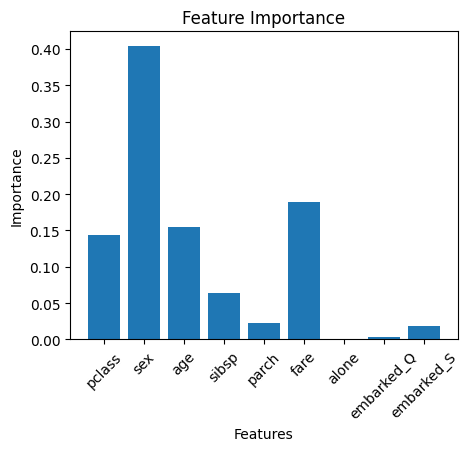

In [61]:
# Ploting the feature importance

plt.figure(figsize=(5,4))

plt.bar(importance_d["features"],
        importance_d["importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

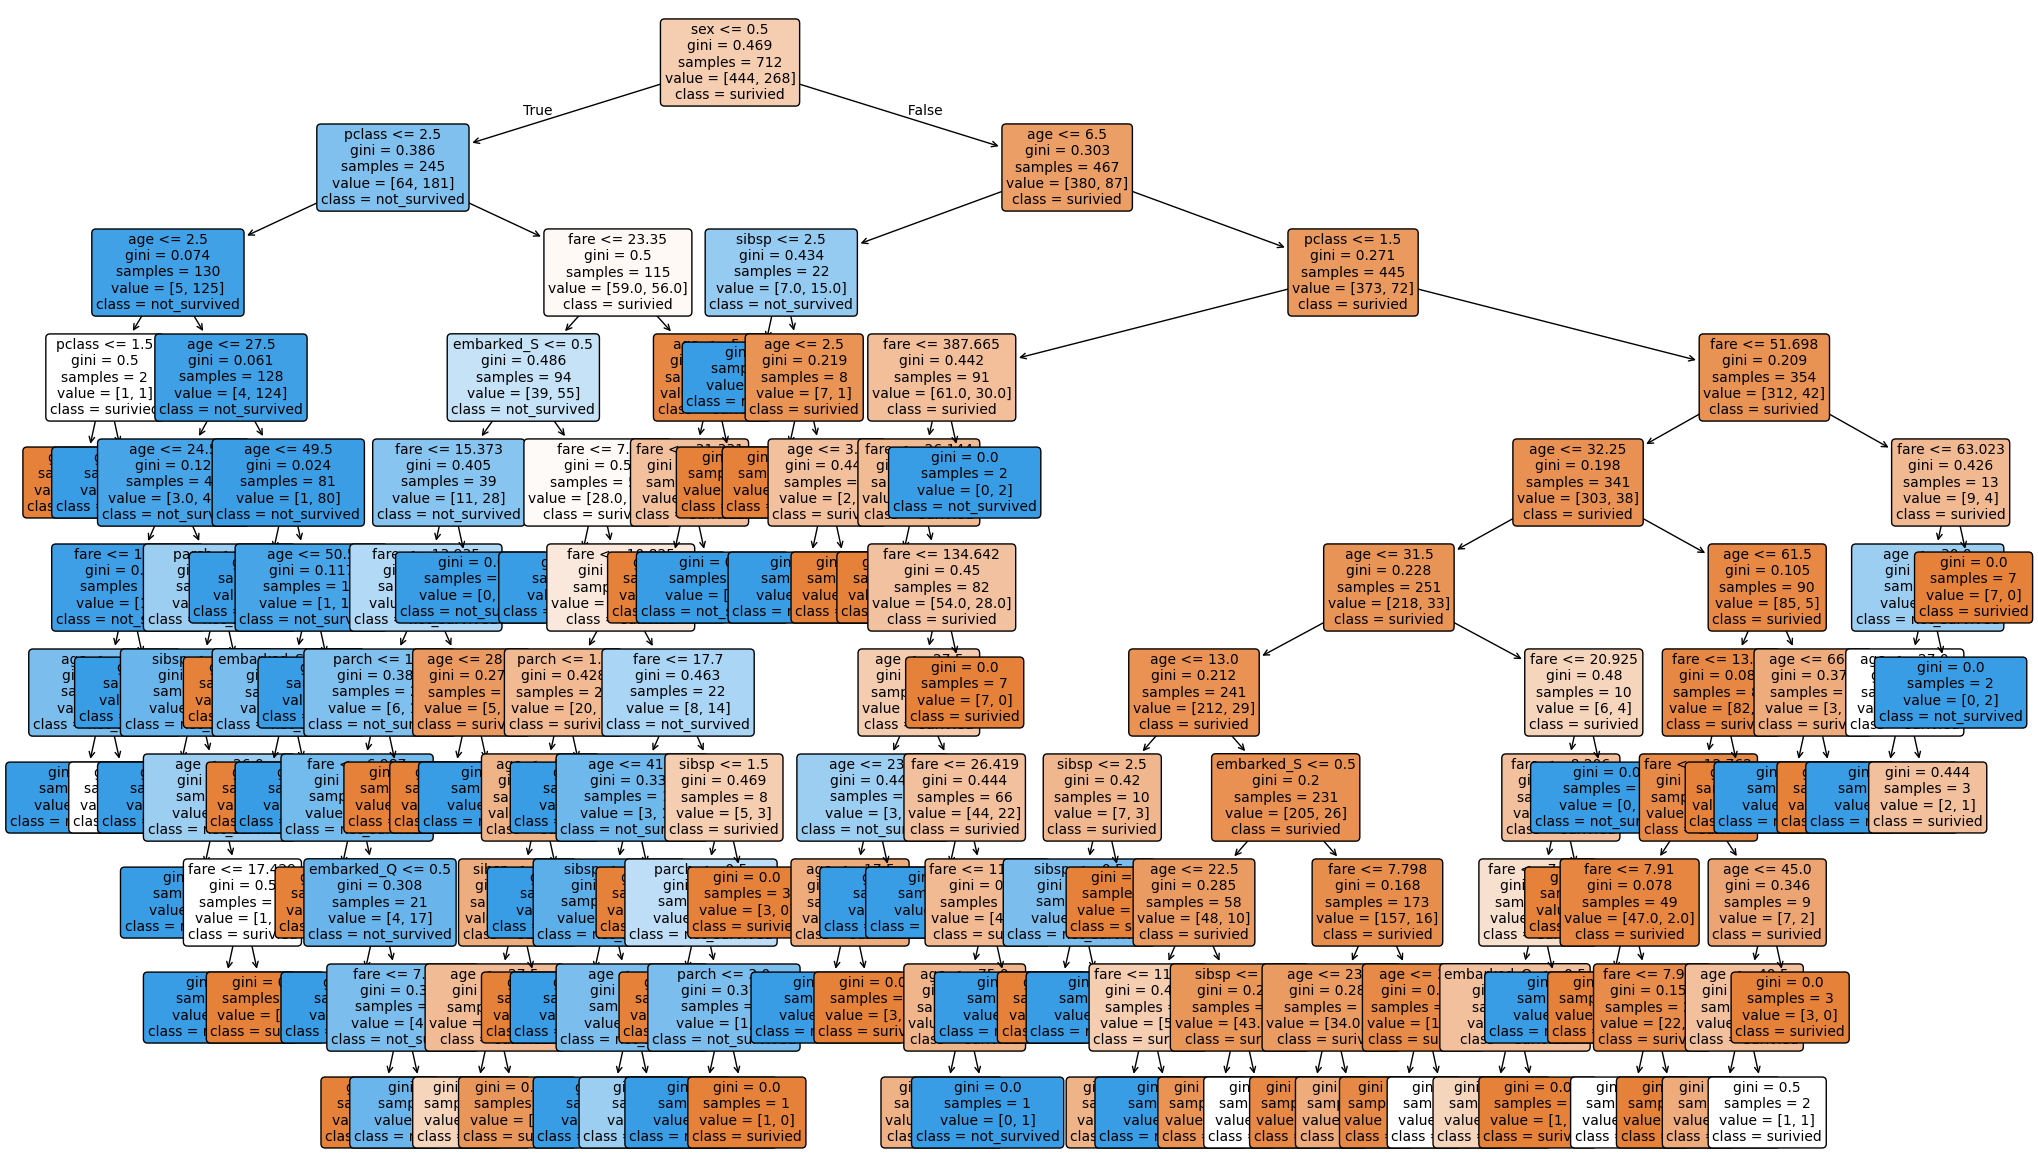

In [70]:
# Tree Visualizing

from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(model3,
          feature_names=x_train.columns,
          class_names=["surivied","not_survived"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()